# Amazon Products – Prices, Ratings, and Association Rules
**Michael W**

**Focus:** Statistical analysis (price vs rating) + full Apriori association rules with clear key takeaways.


## 1. Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Load dataset
try:
    df_raw = pd.read_csv("amazon.csv")
except FileNotFoundError:
    df_raw = pd.read_csv("/mnt/data/amazon.csv")

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## 2. Quick Overview of the Dataset

In [5]:
# Show basic information about the raw dataset (columns, dtypes, non-null counts)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

### Key Takeaways – Dataset Overview
- The dataset contains Amazon products with prices, discounts, ratings, and text fields.
- Price and rating columns are stored as **strings** with symbols (₹, %, commas), so they must be cleaned.
- There are enough rows to support meaningful statistical and association analysis.


## 3. Clean Price, Discount, and Rating Columns

In [8]:
# Clean price, discount, rating, and rating_count columns and build a cleaned DataFrame
df = df_raw.copy()

def clean_money(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace("₹", "").replace(",", "").strip())

df["discounted_price_num"] = df["discounted_price"].apply(clean_money)
df["actual_price_num"] = df["actual_price"].apply(clean_money)
df["discount_pct_num"] = pd.to_numeric(df["discount_percentage"].str.replace("%",""), errors="coerce")
df["rating_num"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count_num"] = pd.to_numeric(df["rating_count"].astype(str).str.replace(",",""), errors="coerce")

core_cols = ["discounted_price_num","actual_price_num","discount_pct_num","rating_num","rating_count_num"]
df_clean = df.dropna(subset=core_cols).copy()

print("Shape after cleaning:", df_clean.shape)
df_clean[core_cols].describe().round(2)


Shape after cleaning: (1462, 21)


,discounted_price_num,actual_price_num,discount_pct_num,rating_num,rating_count_num
count,1462.00,1462.00,1462.00,1462.00,1462.00
mean,3129.98,5453.09,47.67,4.10,18307.38
std,6950.55,10884.47,21.61,0.29,42766.10
min,39.00,39.00,0.00,2.00,2.00
25%,325.00,800.00,32.00,4.00,1191.50
50%,799.00,1670.00,50.00,4.10,5179.00
75%,1999.00,4321.25,63.00,4.30,17342.25
max,77990.00,139900.00,94.00,5.00,426973.00


### Key Takeaways – Cleaning
- Price, discount, and rating-related fields are now **numeric**.
- Rows with missing values in these core columns were removed.
- The cleaned dataset still has **over 1400 products**, so our analysis is based on a solid sample.


## 4. Rating Distribution and Categories

rating_category
High      1109
Medium     312
Low         41
Name: count, dtype: int64


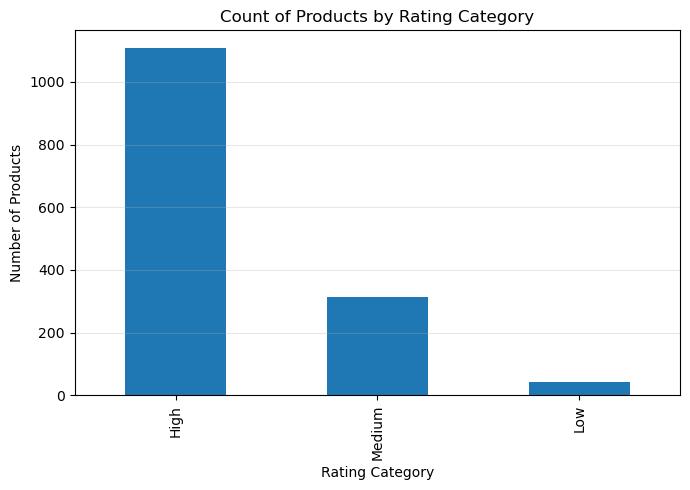

In [11]:
# Define rating categories (Low/Medium/High) and visualize their distribution
def rating_category(r):
    if r < 3.5:
        return "Low"
    elif r < 4.0:
        return "Medium"
    else:
        return "High"

df_clean["rating_category"] = df_clean["rating_num"].apply(rating_category)

print(df_clean["rating_category"].value_counts())

plt.figure(figsize=(7,5))
df_clean["rating_category"].value_counts().plot(kind="bar")
plt.title("Count of Products by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Number of Products")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Key Takeaways – Ratings
- The dataset is dominated by **High** rating products (≥ 4.0).
- **Medium** and especially **Low** rating products are much fewer.
- This right-skewed rating distribution is typical for user review data.


## 5. Statistical Analysis – How Are Prices Related to Ratings?

Correlation between rating and ACTUAL price: 0.1225
Correlation between rating and DISCOUNTED price: 0.1211
Correlation between rating and DISCOUNT percentage: -0.1557


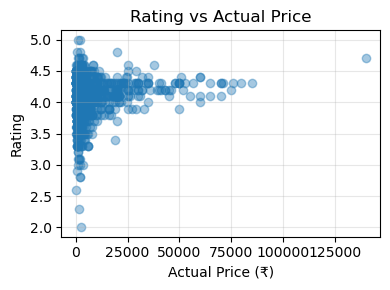

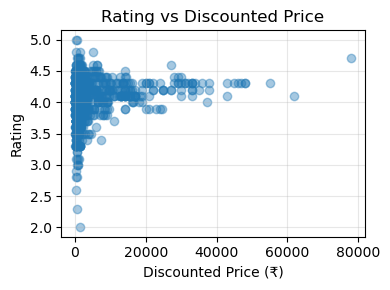

In [14]:
# Compute correlations between rating and price/discount, then visualize with scatter plots
corr_actual = df_clean["rating_num"].corr(df_clean["actual_price_num"])
corr_discounted = df_clean["rating_num"].corr(df_clean["discounted_price_num"])
corr_pct = df_clean["rating_num"].corr(df_clean["discount_pct_num"])

print("Correlation between rating and ACTUAL price:", round(corr_actual,4))
print("Correlation between rating and DISCOUNTED price:", round(corr_discounted,4))
print("Correlation between rating and DISCOUNT percentage:", round(corr_pct,4))

plt.figure(figsize=(4,3))
plt.scatter(df_clean["actual_price_num"], df_clean["rating_num"], alpha=0.4)
plt.xlabel("Actual Price (₹)")
plt.ylabel("Rating")
plt.title("Rating vs Actual Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,3))
plt.scatter(df_clean["discounted_price_num"], df_clean["rating_num"], alpha=0.4)
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Rating")
plt.title("Rating vs Discounted Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Key Takeaways – Price vs Rating
- Correlations between rating and both **actual** and **discounted** price are **very small**.
- This indicates that **price is not a strong predictor** of rating.
- Scatter plots show high ratings at **all price levels**, from low-cost items to expensive ones.
- Discount percentage also shows only a very weak relationship with rating.

 **Conclusion:** Customers in this dataset do **not** rate products primarily based on price or discount level.


## 6. Comparing Prices Across Rating Categories

                 actual_price_num  discounted_price_num  discount_pct_num
rating_category                                                          
High                      6139.50               3586.69             46.07
Low                       2337.95                905.17             58.49
Medium                    3422.59               1798.97             51.94


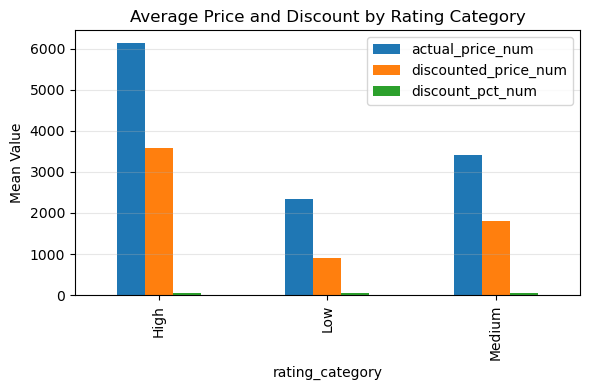

In [17]:
# Compute average price/discount within each rating category and visualize with a bar chart
group_means = df_clean.groupby("rating_category")[
    ["actual_price_num","discounted_price_num","discount_pct_num"]
].mean().round(2)

print(group_means)

group_means.plot(kind="bar", figsize=(6,4))
plt.title("Average Price and Discount by Rating Category")
plt.ylabel("Mean Value")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Key Takeaways – Grouped Price Patterns
- **Low**, **Medium**, and **High** rating categories have **similar average prices**.
- High-rated products are not consistently more or less expensive than others.
- Average discount percentages are close across rating groups as well.

**Conclusion:** Rating categories do **not** show clearly different price or discount behavior.


## 6.5 Data Mining Questions

In this part of the project, we focus on **Apriori and association rules** to answer the following data mining questions:

1. **Which combinations of price tier, discount level, and rating volume are most strongly associated with each rating category (Low, Medium, High)?**  
   - Here we are using full Apriori and association rules to discover patterns like:  
     *“Products in a certain price tier and discount level tend to have High ratings and High rating volume.”*

2. **What pricing and discount patterns (e.g., price tier + discount level) frequently occur together with High ratings, and do they occur more often than we would expect by chance?**  
   - This is answered using support, confidence, and lift from the association rules generated by Apriori.


## 7. Apriori Association Rules

In this part, we:
- Convert numeric variables into categorical tiers.
- One-hot encode the categories.
- Use the **Apriori algorithm** to find frequent itemsets.
- Generate association rules that help explain which conditions are associated with different rating categories.


In [21]:
# Install mlxtend if needed
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    !pip install mlxtend
    from mlxtend.frequent_patterns import apriori, association_rules


### 7.1 Create Categorical Buckets for Apriori

In [23]:
# Create categorical buckets (price tier, discount level, rating volume) for Apriori analysis
df_assoc = df_clean.copy()

# Actual price tier (quartiles)
df_assoc["actual_price_tier"] = pd.qcut(df_assoc["actual_price_num"], 4,
                                        labels=["P1_Low","P2_MidLow","P3_MidHigh","P4_High"])

# Discount level based on percentage
df_assoc["discount_level"] = pd.cut(df_assoc["discount_pct_num"],
                                    [0,25,50,75,100],
                                    labels=["D1_Low","D2_Medium","D3_High","D4_Deep"],
                                    include_lowest=True)

# Rating volume level (number of reviews)
df_assoc["rating_volume_level"] = pd.qcut(df_assoc["rating_count_num"], 3,
                                          labels=["R1_LowVol","R2_MedVol","R3_HighVol"])

cat_cols = ["actual_price_tier","discount_level","rating_category","rating_volume_level"]
df_assoc = df_assoc.dropna(subset=cat_cols).copy()

print("Rows used for Apriori:", df_assoc.shape[0])
df_assoc[cat_cols].head()


Rows used for Apriori: 1462


,actual_price_tier,discount_level,rating_category,rating_volume_level
0,P2_MidLow,D3_High,High,R3_HighVol
1,P1_Low,D2_Medium,High,R3_HighVol
2,P3_MidHigh,D4_Deep,Medium,R2_MedVol
3,P1_Low,D3_High,High,R3_HighVol
4,P1_Low,D3_High,High,R3_HighVol


### Key Takeaways – Categorical Features
- We converted continuous values (price, discount, rating count) into **tiers or levels**.
- Each product is now represented by:
  - a **price tier** (P1–P4),
  - a **discount level** (D1–D4),
  - a **rating category** (Low/Medium/High),
  - a **rating volume level** (R1–R3).
- These categorical features are ideal for Apriori and association rule mining.


### 7.2 One-Hot Encode and Run Apriori

In [26]:
# One-hot encode the selected categorical columns so each product becomes a transaction vector
df_dummies = pd.get_dummies(df_assoc[cat_cols].astype(str))

print("Shape of one-hot encoded data:", df_dummies.shape)
df_dummies.head()

Shape of one-hot encoded data: (1462, 14)


,actual_price_tier_P1_Low,actual_price_tier_P2_MidLow,actual_price_tier_P3_MidHigh,actual_price_tier_P4_High,discount_level_D1_Low,discount_level_D2_Medium,discount_level_D3_High,discount_level_D4_Deep,rating_category_High,rating_category_Low,rating_category_Medium,rating_volume_level_R1_LowVol,rating_volume_level_R2_MedVol,rating_volume_level_R3_HighVol
0,False,True,False,False,False,False,True,False,True,False,False,False,False,True
1,True,False,False,False,False,True,False,False,True,False,False,False,False,True
2,False,False,True,False,False,False,False,True,False,False,True,False,True,False
3,True,False,False,False,False,False,True,False,True,False,False,False,False,True
4,True,False,False,False,False,False,True,False,True,False,False,False,False,True


In [27]:
# Run the full Apriori algorithm to find frequent itemsets with minimum support of 5%
# Run Apriori with minimum support of 5%
frequent_itemsets = apriori(df_dummies, min_support=0.05, use_colnames=True)

print("Number of frequent itemsets:", len(frequent_itemsets))
frequent_itemsets.sort_values("support", ascending=False).head(10)


Number of frequent itemsets: 87


,support,itemsets
8,0.758550,(rating_category_High)
6,0.372093,(discount_level_D3_High)
5,0.350889,(discount_level_D2_Medium)
12,0.333789,(rating_volume_level_R3_HighVol)
10,0.333105,(rating_volume_level_R1_LowVol)
11,0.333105,(rating_volume_level_R2_MedVol)
48,0.281806,"(discount_level_D3_High, rating_category_High)"
56,0.280438,"(rating_volume_level_R3_HighVol, rating_catego..."
43,0.266074,"(rating_category_High, discount_level_D2_Medium)"
55,0.266074,"(rating_category_High, rating_volume_level_R2_..."


### Key Takeaways – Frequent Itemsets
- Apriori found multiple **frequent itemsets** with support ≥ 5%.
- These itemsets capture common combinations of price tier, discount level, rating level, and rating volume.


### 7.3 Generate Association Rules (Support, Confidence, Lift)

In [30]:
# Generate association rules (support, confidence, lift, etc.) from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

print("Number of rules:", len(rules))
rules.head()


Number of rules: 38


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(actual_price_tier_P1_Low),(rating_category_High),0.251710,0.75855,0.190150,0.755435,0.995893,1.0,-0.000784,0.987263,-0.005481,0.231860,-0.012902,0.503056
1,(actual_price_tier_P2_MidLow),(rating_category_High),0.248290,0.75855,0.190834,0.768595,1.013243,1.0,0.002494,1.043409,0.017386,0.233864,0.041603,0.510087
2,(actual_price_tier_P3_MidHigh),(rating_category_High),0.249658,0.75855,0.177839,0.712329,0.939066,1.0,-0.011539,0.839326,-0.079594,0.214168,-0.191432,0.473387
3,(actual_price_tier_P4_High),(rating_category_High),0.250342,0.75855,0.199726,0.797814,1.051762,1.0,0.009829,1.194199,0.065650,0.246830,0.162619,0.530557
4,(discount_level_D1_Low),(rating_category_High),0.175103,0.75855,0.149111,0.851563,1.122619,1.0,0.016287,1.626611,0.132411,0.190061,0.385225,0.524068


In [31]:
# Focus on rules where the consequent includes a rating category
def consequent_has_rating(conseq):
    return any(str(item).startswith("rating_category_") for item in conseq)

rules_rating = rules[rules["consequents"].apply(consequent_has_rating)].copy()
rules_rating_sorted = rules_rating.sort_values(["lift","confidence"], ascending=False)

rules_rating_sorted.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11,"(discount_level_D1_Low, actual_price_tier_P1_Low)",(rating_category_High),0.067031,0.75855,0.059508,0.887755,1.170332,1.0,0.008661,2.151101,0.155998,0.077679,0.535122,0.483102
15,"(rating_volume_level_R3_HighVol, actual_price_...",(rating_category_High),0.073871,0.75855,0.064295,0.870370,1.147413,1.0,0.008260,1.862615,0.138722,0.083704,0.463120,0.477566
34,"(rating_volume_level_R3_HighVol, discount_leve...",(rating_category_High),0.115595,0.75855,0.100547,0.869822,1.146691,1.0,0.012863,1.854776,0.144646,0.129973,0.460851,0.501187
37,"(rating_volume_level_R3_HighVol, discount_leve...",(rating_category_High),0.115595,0.75855,0.100547,0.869822,1.146691,1.0,0.012863,1.854776,0.144646,0.129973,0.460851,0.501187
31,"(rating_volume_level_R3_HighVol, discount_leve...",(rating_category_High),0.067715,0.75855,0.058140,0.858586,1.131878,1.0,0.006774,1.707397,0.124975,0.075690,0.414313,0.467616
30,"(discount_level_D1_Low, rating_volume_level_R2...",(rating_category_High),0.075239,0.75855,0.064295,0.854545,1.126551,1.0,0.007223,1.659969,0.121475,0.083556,0.397579,0.469653
4,(discount_level_D1_Low),(rating_category_High),0.175103,0.75855,0.149111,0.851563,1.122619,1.0,0.016287,1.626611,0.132411,0.190061,0.385225,0.524068
36,"(discount_level_D3_High, rating_volume_level_R...",(rating_category_High),0.107387,0.75855,0.090287,0.840764,1.108384,1.0,0.008829,1.516306,0.109550,0.116402,0.340503,0.479895
20,"(actual_price_tier_P2_MidLow, rating_volume_le...",(rating_category_High),0.081395,0.75855,0.068399,0.840336,1.107819,1.0,0.006657,1.512240,0.105949,0.088652,0.338729,0.465254
10,(rating_volume_level_R3_HighVol),(rating_category_High),0.333789,0.75855,0.280438,0.840164,1.107592,1.0,0.027242,1.510611,0.145811,0.345409,0.338016,0.604933


### Key Takeaways – Full Apriori Association Rules
- We generated association rules from frequent itemsets and filtered them to those that **predict rating categories**.
- For each rule we use:
  - **Support** – how often the rule occurs in the dataset.
  - **Confidence** – how often the rating appears when the condition is present.
  - **Lift** – how much more likely the rating is, compared to chance.
- Rules with **lift > 1** indicate that the feature combination (e.g., a price tier and discount level) is **positively associated** with a specific rating level.

 **Conclusion:** Full Apriori reveals some **mild patterns** where certain price/discount/volume combinations are more likely to be highly rated, but the overall effect is limited because high ratings are common across most products.


## 8. Final Key Takeaways
1. **Price does not strongly determine rating.**  
   - Correlations between price and rating are very small.
   - High ratings appear across both low and high price ranges.

2. **Discount level is also not a strong predictor of rating.**  
   - Deep discounts are not clearly associated with better or worse ratings.

3. **Rating categories share similar average prices and discounts.**  
   - Low-, Medium-, and High-rated products have similar mean actual and discounted prices.

4. **Full Apriori association rules add multi-feature insight.**  
   - Some combinations of price tier, discount level, and rating volume show slightly higher lift for High ratings.
   - However, these effects are modest because the dataset is generally skewed toward high ratings.

 **Overall Conclusion:**  
Product ratings in this Amazon dataset appear to be driven more by **product quality and other attributes** than by price or discount behavior alone. Prices and discounts play only a minor role in explaining rating differences.
